## Inference
Test if we can run the saved models

In [52]:
import sys
import xarray as xr
import torch
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('../src')
from Inference import sample_unet, sample_model_EDS
from Network import UNet, EDMPrecond
from DatasetUS import UpscaleDatasetCERRA

from torch.utils.data.dataloader import DataLoader

Set up models

In [61]:
# Subset of years
year_start = 2020
year_end = 2020

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# Dirs
run_nbr = '01'
datadir="../data/CERRA-ERA5/"
model_dir = f"../src/runs_unet/run_{run_nbr}"


cpu


Get checkpoints of models for both UNet and Diffusion

In [62]:
# Get models
# unet
model_unet = UNet((256, 256), 3, 1, label_dim=1, use_diffuse=False).to(device)
model_unet.load_state_dict(torch.load(f"{model_dir}/run_{run_nbr}.pt", map_location='cpu'))
# diffusion
# model_diff = EDMPrecond((256, 128), 8, 3).to(device)
# model_diff.load_state_dict(torch.load(f"{model_dir}/Model_chpt/diffusion.pt", map_location='cpu'))

<All keys matched successfully>

Open datasets

In [64]:

dataset_test = UpscaleDatasetCERRA(datadir, year_start=year_start, year_end=year_end,
                              constant_variables=["lsm", "orog"])

x = dataset_test.x
y = dataset_test.y
ny, nx = len(y), len(x)


Opening CERRA files
All files accessed. Creating tensors
CERRA tensor: torch.Size([366, 1, 256, 256])
Opening ERA files
ERA5 tensor: torch.Size([366, 1, 256, 256])
tensor([268.6730]) tensor([298.1122])
Opening constant variables file (e.g. land-sea mask, topography)
Normalize orog
orog stats -- mean: <xarray.DataArray 'orog' ()> Size: 4B
array(125.51304, dtype=float32), std.: <xarray.DataArray 'orog' ()> Size: 4B
array(240.18056, dtype=float32)
Dataset initialized.


In [65]:
BATCH_SIZE = 1
dataloader = DataLoader(dataset_test,
                        batch_size=BATCH_SIZE,
                        shuffle=True)

 Sample our batch of 1 for both models

In [ ]:
# t = 200   # time index
test_batch = next(iter(dataloader))

# Run models
coarse, fine, predicted_unet = sample_unet(test_batch, model_unet, 
                                           device, dataset_test)
# _, _, predicted_diff = sample_model_EDS(test_batch, model_diff, 
#                                        device, dataset_test, num_steps=40)

coarse = coarse.detach().numpy()
fine = fine.detach().numpy()
predicted_unet = predicted_unet.detach().numpy()
# predicted_diff = predicted_diff.detach().numpy()

print(coarse.shape, fine.shape, predicted_unet.shape) #, predicted_diff.shape)

# Extract temporal information
year = test_batch["year"].item() # year
doy = test_batch["doy"].item()  # day of year
# hour = test_batch["hour"].item()  # hour

# Convert to a readable date
from datetime import datetime, timedelta
year = year * 100 + 1985
doy = doy * 366.
# hour = hour * 24
date = datetime(round(year)-1, 12, 31) + timedelta(days=round(doy))
date_str = date.strftime("%d-%m-%Y") # %H:%M")

print(date_str)

(1, 1, 256, 256) (1, 1, 256, 256) (1, 1, 256, 256)
13-04-2020


## Plot
Plot all variables for this one timestep

In [ ]:
# Variables
varnames = ["VAR_2T"]

# Symmetric range around 0
# vmax = [max(abs(fine.min()), abs(fine.max()))-273.15]

# Fixed values
# vmax = [25]

# vmin = [-1*vmax[i] for i in range(len(vmax))]

# Fitted
vmax = [max(fine.max(), coarse.max(), predicted_unet.max())-273.15]
vmin = [min(fine.min(), coarse.min(), predicted_unet.min())-273.15]



cmaps = ["RdBu_r"]

plot_varnames = ["Temperature"]
plot_var_labels = ["°C"]
plt.rcParams.update({'font.size': 18})

<Figure size 640x480 with 0 Axes>

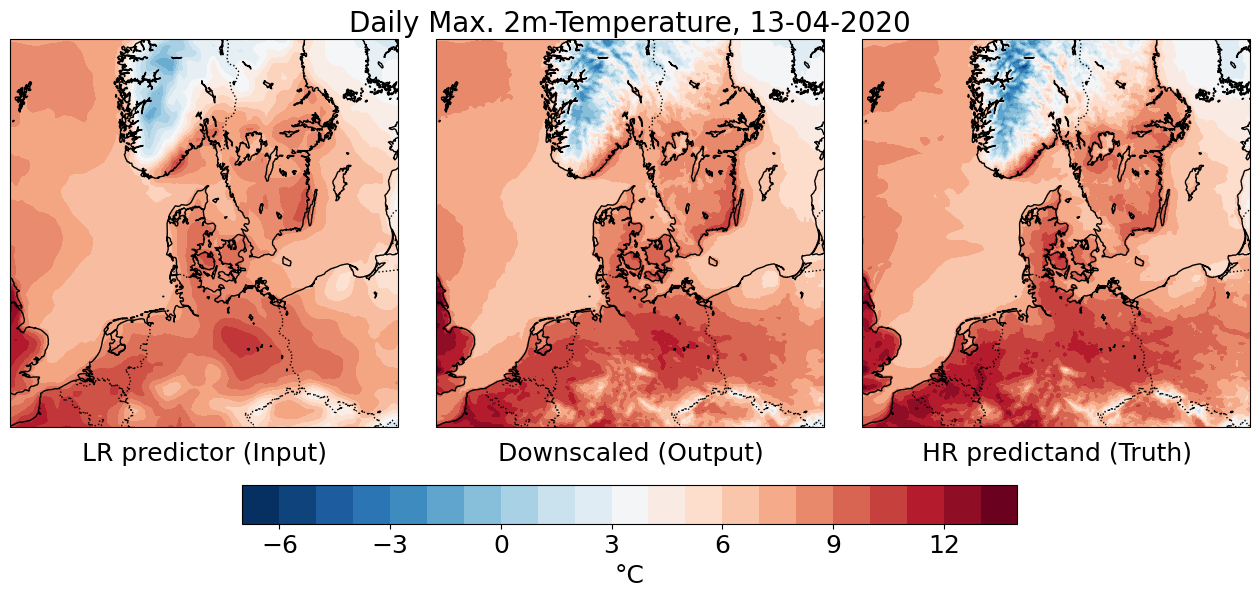

In [72]:
from skimage.measure import block_reduce

## HORIZONTAL PLOT

plt.clf()
# fig, axs = plt.subplots(4,3, figsize=(16, 10.2),
#                         subplot_kw={'projection': ccrs.PlateCarree()},
#                         gridspec_kw={'wspace': 0.1,
#                                      'hspace': 0.1})
fig, axs = plt.subplots(1,3, figsize=(16,12),
                        subplot_kw={'projection': dataset_test.projection},
                        gridspec_kw={'wspace': 0.1,
                                     'hspace': 0.1})

projection = dataset_test.projection

for i, varname in enumerate(varnames):
    
    coarse_i = coarse[0, i]

   #  Reverse interpolation
   #  coarse_pad = np.pad(coarse_i, ((0, 5 - coarse_i.shape[0]%5), (0, 5 - coarse_i.shape[1]%5)), 
   #                  mode='constant', constant_values=np.nan)
   #  coarse_small = block_reduce(coarse_pad, block_size=5, func=np.nanmean)
   #  coarse_i = np.repeat(np.repeat(coarse_small, 5, axis=0), 5, axis=1)[2:-2, 2:-2]

    ax = axs[0]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
    pcm = ax.contourf(x, y, coarse_i-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                #    shading='nearest',  # for pcolormesh, instead of levels
                   levels=20,
                   cmap=cmaps[i], transform=projection)
    if i == 0:
        plt.text(x[len(x) // 2], y[0] - y[-1]/15, f"LR predictor (Input)", transform=projection,
                 ha='center', va='center', zorder=10)

    ax = axs[1]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
    # ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)
    pcm = ax.contourf(x, y, predicted_unet[0, i]-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                #    shading='nearest',
                   levels=20,
                   cmap=cmaps[i], transform=projection)
    
    if i == 0:
        plt.text(x[len(x) // 2], y[0] - y[-1]/15, f"Downscaled (Output)", transform=projection,
                 ha='center', va='center', zorder=10)

        
    plt.title(f"Daily Max. 2m-Temperature, {date_str}", fontsize=20)
        
    ax = axs[2]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
    pcm = ax.contourf(x, y, fine[0, i]-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                #    shading='nearest',
                   levels=20,
                   cmap=cmaps[i], transform=projection)

    if i == 0:
        plt.text(x[len(x) // 2], y[0] - y[-1]/15, f"HR predictand (Truth)", transform=projection,
                 ha='center', va='center', zorder=10)

    # ax = axs[3, i]
    # plt.sca(ax)
    # ax.coastlines()
    # ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    # pcm = plt.pcolormesh(lon, lat, predicted_diff[0, i]-273.15,
    #                vmin=vmin[i], vmax=vmax[i],
    #                shading='nearest',
    #                cmap=cmaps[i])
    # if i == 0:
    #     plt.text(lon[0]-2, lat[len(lat) // 2], f"Diffusion", transform=ccrs.PlateCarree(),
    #              rotation='vertical', ha='right', va='center', zorder=10)
    # cax = axs[3, i].inset_axes([0., -0.25, 1, 0.1])
    
    cax = axs[1].inset_axes([-0.5, -0.25, 2, 0.1])
    plt.colorbar(pcm, cax = cax, orientation="horizontal", label=f"{plot_var_labels[i]}")

    axs[0].set_xlim(axs[1].get_xlim())
    axs[0].set_ylim(axs[1].get_ylim())

plt.show()

<Figure size 640x480 with 0 Axes>

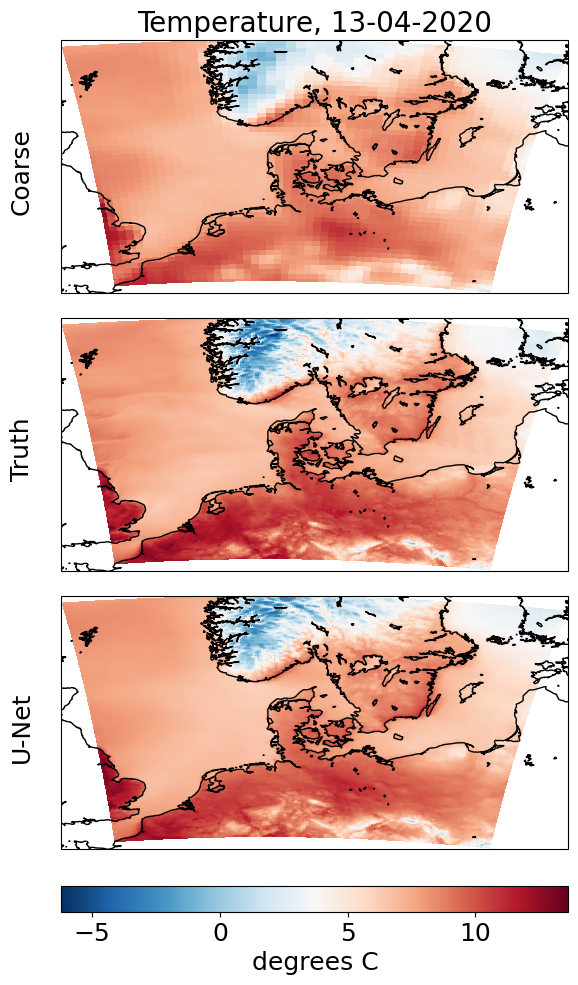

In [69]:
## VERTICAL PLOT

plt.clf()
# fig, axs = plt.subplots(4,3, figsize=(16, 10.2),
#                         subplot_kw={'projection': ccrs.PlateCarree()},
#                         gridspec_kw={'wspace': 0.1,
#                                      'hspace': 0.1})
fig, axs = plt.subplots(3,1, figsize=(16, 10.5),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        gridspec_kw={'wspace': 0.1,
                                     'hspace': 0.1})

projection = dataset_test.projection

for i, varname in enumerate(varnames):

    coarse_i = coarse[0, i]
    coarse_pad = np.pad(coarse_i, ((0, 5 - coarse_i.shape[0]%5), (0, 5 - coarse_i.shape[1]%5)), 
                    mode='constant', constant_values=np.nan)
    coarse_small = block_reduce(coarse_pad, block_size=5, func=np.nanmean)
    coarse_up = np.repeat(np.repeat(coarse_small, 5, axis=0), 5, axis=1)[2:-2, 2:-2]
    ax = axs[0]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    pcm = plt.pcolormesh(x, y, coarse_up-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i], transform=projection)
    if i == 0:
        plt.text(x[0]-x[-1]/6, y[len(y) // 2], f"Coarse", transform=projection,
                 rotation='vertical', ha='center', va='center', zorder=10)
    plt.title(f"{plot_varnames[i]}, {date_str}", fontsize=20)

    ax = axs[1]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    pcm = plt.pcolormesh(x, y, fine[0, i]-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i], transform=projection)
    if i == 0:
        plt.text(x[0]-x[-1]/6, y[len(y) // 2], f"Truth", transform=projection,
                 rotation='vertical', ha='center', va='center', zorder=10)

    ax = axs[2]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    pcm = plt.pcolormesh(x, y, predicted_unet[0, i]-273.15,
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i], transform=projection)
    if i == 0:
        plt.text(x[0]-x[-1]/6, y[len(y) // 2], f"U-Net", transform=projection,
                 rotation='vertical', ha='center', va='center', zorder=10)

    # ax = axs[3, i]
    # plt.sca(ax)
    # ax.coastlines()
    # ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    # pcm = plt.pcolormesh(lon, lat, predicted_diff[0, i]-273.15,
    #                vmin=vmin[i], vmax=vmax[i],
    #                shading='nearest',
    #                cmap=cmaps[i])
    # if i == 0:
    #     plt.text(lon[0]-2, lat[len(lat) // 2], f"Diffusion", transform=ccrs.PlateCarree(),
    #              rotation='vertical', ha='right', va='center', zorder=10)
    # cax = axs[3, i].inset_axes([0., -0.25, 1, 0.1])
    
    cax = axs[2].inset_axes([0., -0.25, 1, 0.1])
    plt.colorbar(pcm, cax = cax, orientation="horizontal", label=f"{plot_var_labels[i]}")

    axs[0].set_xlim(axs[1].get_xlim())
    axs[0].set_ylim(axs[1].get_ylim())

plt.show()